In [26]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
import os

In [ ]:
def set_seed(seed=42):
    """Фиксирует все сиды для воспроизводимости"""
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    tf.random.set_seed(seed)
    print(f"Сид установлен на {seed}.")

set_seed(42)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f" Доступно GPU: {len(gpus)}")
    for gpu in gpus:
        print(f" - {gpu.name}")
else:
    print(" GPU не найден. Включите акселератор в настройках Kaggle!")

strategy = tf.distribute.MirroredStrategy()
print(f"Количество используемых GPU: {strategy.num_replicas_in_sync}")

Сид установлен на 42.
 Доступно GPU: 2
 - /physical_device:GPU:0
 - /physical_device:GPU:1
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Количество используемых GPU: 2


In [28]:
@tf.keras.utils.register_keras_serializable()
def asymmetric_quad_loss(y_true, y_pred):
    """
    Кастомная функция потерь (Asymmetric MSE).
    Заставляет модель ловить пики, математически максимизируя R2.
    """
    error = y_true - y_pred
    squared_error = tf.square(error)
    
    penalty_under = 2.0  # Штраф за недобор (пропуск пика)
    penalty_over = 1.0   # Штраф за перепрогноз
    
    loss = tf.where(error > 0, 
                    squared_error * penalty_under, 
                    squared_error * penalty_over)
    return tf.reduce_mean(loss)

def evaluate_and_plot_predictions(y_test_real, y_pred_real, dates_test, model_name="Модель", n_hours=168, save_path=None):
    mae_overall = mean_absolute_error(y_test_real, y_pred_real)
    rmse_overall = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    epsilon = 1e-10 
    mape_overall = np.mean(np.abs((y_test_real - y_pred_real) / (y_test_real + epsilon))) * 100
    r2_overall = r2_score(y_test_real, y_pred_real)

    print(f"\n{f'Итоговые метрики: {model_name}':^55}")
    print(f"MAE:      {mae_overall:>10.2f} Вт")
    print(f"RMSE:     {rmse_overall:>10.2f} Вт")
    print(f"MAPE:     {mape_overall:>10.2f} %")
    print(f"R2:       {r2_overall:>10.4f}")

    step_idx = 0 
    plt.figure(figsize=(18, 6))
    plt.plot(dates_test[:n_hours], y_test_real[:n_hours, step_idx], 
             label='Фактическое потребление', color='black', linewidth=2, alpha=0.7)
    plt.plot(dates_test[:n_hours], y_pred_real[:n_hours, step_idx], 
             label=f'Прогноз {model_name}', color='darkorange', linewidth=2, linestyle='--')

    plt.fill_between(dates_test[:n_hours], y_test_real[:n_hours, step_idx], y_pred_real[:n_hours, step_idx], 
                     where=(y_test_real[:n_hours, step_idx] > y_pred_real[:n_hours, step_idx]),
                     color='red', alpha=0.15, label='Недопрогноз')

    plt.title(f'Сравнение прогноза {model_name} и факта на тестовой неделе', fontsize=14)
    plt.xlabel('Дата и время', fontsize=12)
    plt.ylabel('Потребление (Вт)', fontsize=12)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    return {'mae': mae_overall, 'rmse': rmse_overall, 'mape': mape_overall, 'r2': r2_overall}

def plot_training_history_with_lr(history, start_epoch=5, save_path=None):
    hist = history.history
    loss = hist.get('loss', [])
    val_loss = hist.get('val_loss', [])
    mae = hist.get('mae', [])
    val_mae = hist.get('val_mae', [])
    lrs = hist.get('learning_rate') or hist.get('lr', [])
    
    if len(loss) < start_epoch:
        start_epoch = 1 
        
    s = start_epoch - 1
    epochs = range(start_epoch, len(loss) + 1)
    
    lr_drop_epochs = []
    if len(lrs) > 0:
        for i in range(1, len(lrs)):
            if lrs[i] < lrs[i-1]:
                lr_drop_epochs.append(i + 1)
                
    visible_drops = [e for e in lr_drop_epochs if e >= start_epoch]

    fig, ax = plt.subplots(1, 2, figsize=(18, 6))

    ax[0].plot(epochs, loss[s:], label='Train Loss', color='steelblue', linewidth=2)
    if len(val_loss) > 0:
        ax[0].plot(epochs, val_loss[s:], label='Val Loss', color='darkorange', linewidth=2, linestyle='--')
    for drop_e in visible_drops:
        ax[0].axvline(x=drop_e, color='grey', linestyle=':', alpha=0.8)
    if visible_drops:
        ax[0].plot([], [], color='grey', linestyle=':', label='LR Drop')

    ax[0].set_title(f'История Loss (с {start_epoch} эпохи)', fontsize=13)
    ax[0].set_xlabel('Эпоха', fontsize=11)
    ax[0].set_ylabel('Asymmetric Loss', fontsize=11)
    ax[0].set_xlim(left=start_epoch) 
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    if len(mae) > 0:
        ax[1].plot(epochs, mae[s:], label='Train MAE', color='forestgreen', linewidth=2)
    if len(val_mae) > 0:
        ax[1].plot(epochs, val_mae[s:], label='Val MAE', color='crimson', linewidth=2, linestyle='--')
    for drop_e in visible_drops:
        ax[1].axvline(x=drop_e, color='grey', linestyle=':', alpha=0.8)
    if visible_drops:
        ax[1].plot([], [], color='grey', linestyle=':', label='LR Drop')

    ax[1].set_title(f'История MAE (с {start_epoch} эпохи)', fontsize=13)
    ax[1].set_xlabel('Эпоха', fontsize=11)
    ax[1].set_ylabel('MAE', fontsize=11)
    ax[1].set_xlim(left=start_epoch)
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

def create_sequences(X_data, y_data, dates_array, seq_len, horizon):
    X, y, dates = [], [], []
    for i in range(len(X_data) - seq_len - horizon + 1):
        X.append(X_data[i : i + seq_len])
        y.append(y_data[i + seq_len : i + seq_len + horizon]) 
        dates.append(dates_array[i + seq_len]) 
    return np.array(X), np.array(y), np.array(dates)


def asymmetric_profit_loss(y_true, y_pred):
    """
    Кастомная функция потерь.
    Штрафует сильнее за недопрогноз (когда факт > прогноза).
    Заставляет модель предсказывать пики с запасом.
    """
    error = y_true - y_pred
    penalty_under = 3.0 
    penalty_over = 1.0
    
    loss = tf.where(error > 0, 
                    tf.square(error) * penalty_under, 
                    tf.square(error) * penalty_over)
    
    return tf.reduce_mean(loss)


#  Подготовка данных

In [ ]:
df_features = pd.read_csv('/kaggle/input/datasets/yourdadi/data-kaggle/features.csv')
target_col = 'consumption'
feature_cols = [col for col in df_features.columns if col not in ['timestamp', target_col]]

# 1. Разбиение на Train / Test (80/20)
split_idx = int(len(df_features) * 0.8)
train_df = df_features.iloc[:split_idx].copy()
test_df = df_features.iloc[split_idx:].copy()

train_X_raw = train_df[feature_cols].values
test_X_raw = test_df[feature_cols].values
train_y_raw = train_df[target_col].values
test_y_raw = test_df[target_col].values

train_dates = pd.to_datetime(train_df['timestamp']).values
test_dates = pd.to_datetime(test_df['timestamp']).values

SEQ_LEN = 168  
HORIZON = 24   

X_train, y_train, dates_train = create_sequences(train_X_raw, train_y_raw, train_dates, SEQ_LEN, HORIZON)
X_test, y_test, dates_test = create_sequences(test_X_raw, test_y_raw, test_dates, SEQ_LEN, HORIZON)

n_features = X_train.shape[2]
x_scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, n_features)
X_test_2d  = X_test.reshape(-1, n_features)

X_train_scaled = x_scaler.fit_transform(X_train_2d).reshape(X_train.shape)
X_test_scaled  = x_scaler.transform(X_test_2d).reshape(X_test.shape)

joblib.dump(x_scaler, '/kaggle/working/scaler_hybrid.joblib')


y_scaler = StandardScaler()

y_train_2d = y_train.reshape(-1, HORIZON)
y_test_2d = y_test.reshape(-1, HORIZON)

y_train_scaled = y_scaler.fit_transform(y_train_2d).reshape(y_train.shape)
y_test_scaled = y_scaler.transform(y_test_2d).reshape(y_test.shape)

joblib.dump(y_scaler, '/kaggle/working/y_scaler_hybrid.joblib')

print(f"Обучающая выборка X: {X_train_scaled.shape} | Y: {y_train_scaled.shape}")
print(f"Тестовая выборка X:  {X_test_scaled.shape} | Y: {y_test_scaled.shape}")

=== ДАННЫЕ ГОТОВЫ К ОБУЧЕНИЮ ===
Обучающая выборка X: (6681, 168, 57) | Y: (6681, 24)
Тестовая выборка X:  (1528, 168, 57) | Y: (1528, 24)


# Архитектура Hybrid network

In [30]:
def build_model_machines(input_shape, horizon):
    l2_reg = 1e-4
    inputs = layers.Input(shape=input_shape) # (48, 57)

    # --- 1. СЖАТИЕ ВРЕМЕНИ (48 -> 24) ---
    # Сжимаем 2 суток в 24 "супер-шага", чтобы вернуться к привычной модели
    x = layers.Conv1D(64, kernel_size=3, strides=2, padding='same', activation='mish',
                      kernel_regularizer=regularizers.l2(l2_reg))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.SpatialDropout1D(0.2)(x)

    # --- 2. ГЛУБОКАЯ ЧАСТЬ (CNN + LSTM + Attention) ---
    x = layers.Conv1D(128, kernel_size=3, padding='same', activation='mish')(x)
    x = layers.MaxPooling1D(pool_size=2)(x) # 24 -> 12

    x = layers.LSTM(128, return_sequences=True, dropout=0.2)(x)
    
    att = layers.MultiHeadAttention(num_heads=8, key_dim=32)(x, x)
    x = layers.Add()([x, att])
    x = layers.LayerNormalization()(x)

    # Агрегация истории
    avg_pool = layers.GlobalAveragePooling1D()(x)
    max_pool = layers.GlobalMaxPooling1D()(x)
    
    # --- 3. ИНЪЕКЦИЯ ТЕКУЩИХ ПРИЗНАКОВ (Wide part) ---
    # Берем признаки только последнего часа из последовательности (индекс -1)
    current_features = layers.Lambda(lambda x: x[:, -1, :])(inputs)
    current_feat_dense = layers.Dense(32, activation='mish')(current_features)

    # --- 4. ОБЪЕДИНЕНИЕ (Wide & Deep) ---
    concat = layers.Concatenate()([avg_pool, max_pool, current_feat_dense])
    
    # Голова
    x_head = layers.Dense(256, activation='mish', kernel_regularizer=regularizers.l2(l2_reg))(concat)
    x_head = layers.Dropout(0.4)(x_head)
    x_head = layers.Dense(128, activation='mish')(x_head)
    
    outputs = layers.Dense(horizon, activation='linear')(x_head)

    return models.Model(inputs=inputs, outputs=outputs, name="Hybrid_Model")

In [31]:
model_hybrid = build_model_machines((SEQ_LEN, n_features), HORIZON)

# Используем Nadam, он отлично работает с асимметричными функциями
model_hybrid.compile(
    optimizer=tf.keras.optimizers.Nadam(learning_rate=5e-4, clipvalue=1.0), 
    loss=asymmetric_profit_loss, # Ваша функция экономики
    metrics=['mae']
)

callbacks_list = [
    callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=15, 
        restore_best_weights=True, 
        verbose=1
    ),
    
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.75, 
        patience=10, 
        min_lr=1e-6, 
        verbose=1
    ),
    callbacks.TerminateOnNaN()
]

model_hybrid.summary()

history_hybrid = model_hybrid.fit(
    X_train_scaled, y_train_scaled, # Обучаем на StandardScaler данных!
    epochs=300,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks_list,
    verbose=1
)

Model: "Hybrid_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 168, 57)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 84, 64)    │     11,008 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 84, 64)    │        256 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 84, 64)    │          0 │ batch_normalizat… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 84, 128)   │     24,704 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 42, 128)   │          0 │ conv1d_7[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 42, 128)   │    131,584 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 42, 128)   │    131,968 │ lstm_4[0][0],     │
│ (MultiHeadAttentio… │                   │            │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 42, 128)   │          0 │ lstm_4[0][0],     │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 42, 128)   │        256 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 57)        │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      1,856 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 288)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │     73,984 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 256)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │     32,896 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 24)        │      3,096 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 411,608 (1.57 MB)

 Trainable params: 411,480 (1.57 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/300
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 1.6922 - mae: 0.8542 - val_loss: 0.2246 - val_mae: 0.2652 - learning_rate: 5.0000e-04
Epoch 2/300
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.2812 - mae: 0.3287 - val_loss: 0.1648 - val_mae: 0.2232 - learning_rate: 5.0000e-04
Epoch 3/300
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.2202 - mae: 0.2850 - val_loss: 0.1477 - val_mae: 0.2048 - learning_rate: 5.0000e-04
Epoch 4/300
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1927 - mae: 0.2630 - val_loss: 0.1378 - val_mae: 0.1937 - learning_rate: 5.0000e-04
Epoch 5/300
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1779 - mae: 0.2517 - val_loss: 0.1225 - val_mae: 0.1850 - learning_rate: 5.0000e-04
Epoch 6/300
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.1649 - mae: 0.2406 - val_loss: 0.1218 - val_mae: 0.1855 - learning_rate: 5.0000e-04
Epoch 7/300
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.1555 - mae: 0.2325 - val_loss: 0.1143 - val_mae: 0.1713 - lear

# Визуализация обучения и предсказаний

Выполнение прогнозов...

            МЕТРИКИ НА ТЕСТОВЫХ ДАННЫХ            

         Итоговые метрики: Hybrid_model_Final          
MAE:       134597.14 Вт
RMSE:      187121.39 Вт
MAPE:           3.70 %
R2:           0.9639

               СРАВНЕНИЕ ТОЧНОСТИ (TRAIN VS TEST)                
Метрика |              Train |               Test |   Разрыв %
-----------------------------------------------------------------
R2      |          0.9912    |          0.9639    |      2.76%
MAPE    |          2.1552 %  |          3.7002 %  |     71.69%
MAE     |      67714.7386 Вт |     134597.1412 Вт |     98.77%
RMSE    |      86165.5991 Вт |     187121.3863 Вт |    117.16%


['/kaggle/working/y_scaler_hybrid.joblib']

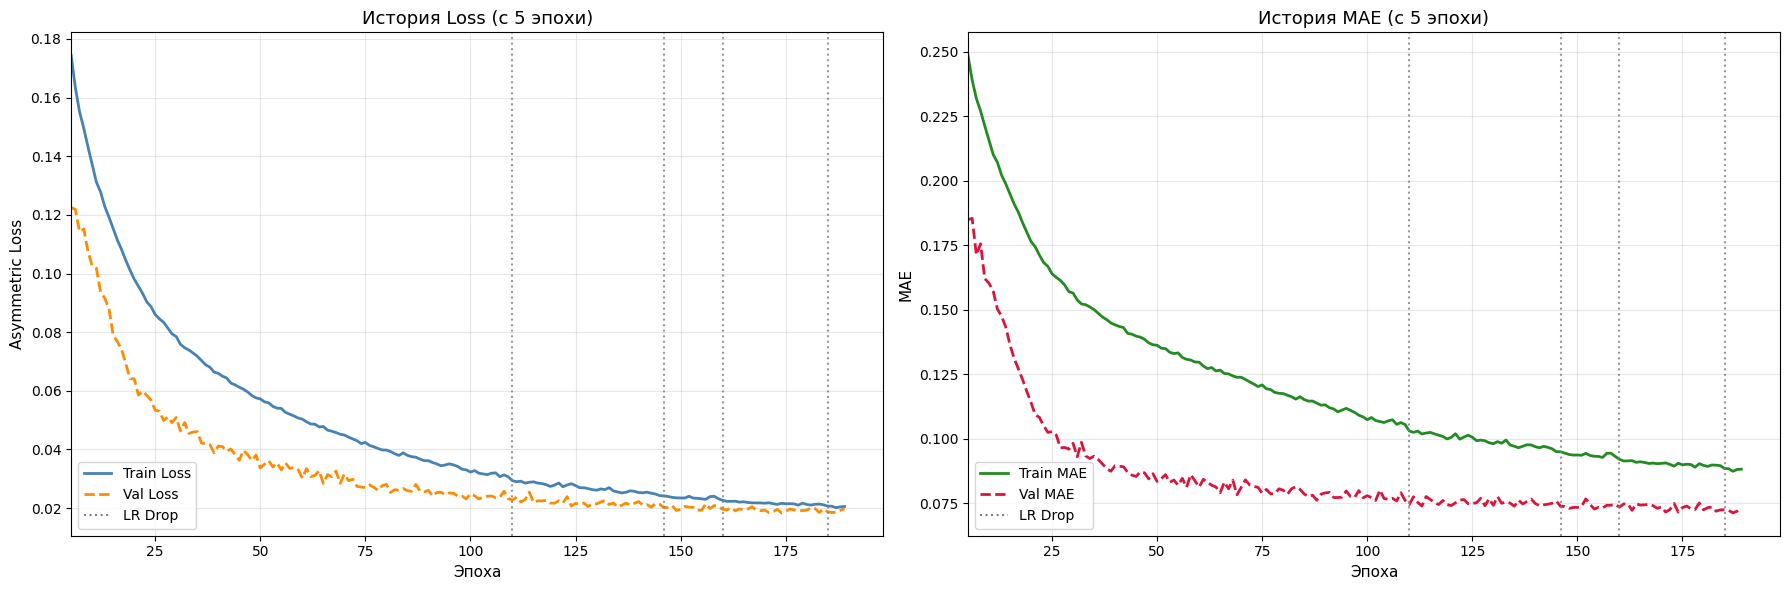

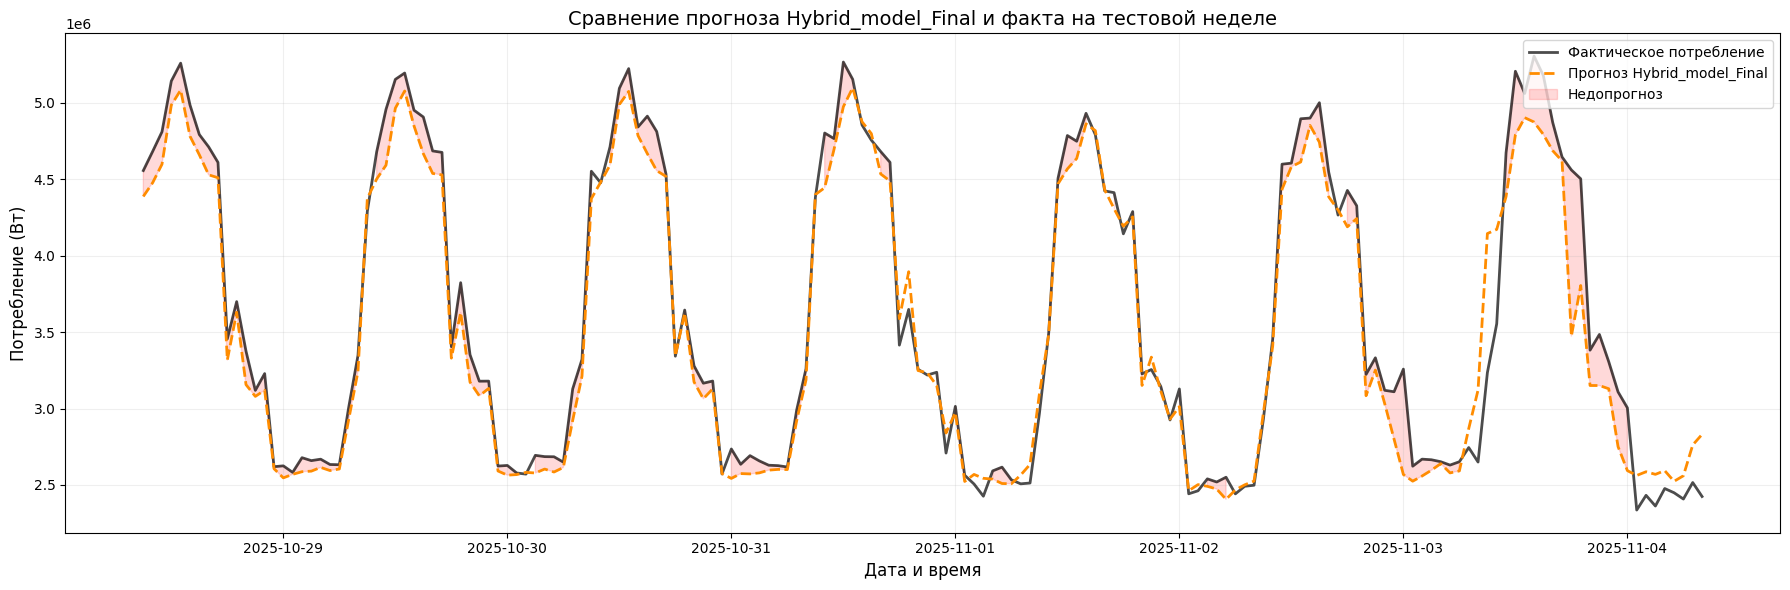

In [ ]:

y_pred_test_scaled = model_hybrid.predict(X_test_scaled, verbose=0)
y_pred_train_scaled = model_hybrid.predict(X_train_scaled, verbose=0)

# 2. Обратное масштабирование
y_pred_test_real = y_scaler.inverse_transform(y_pred_test_scaled.reshape(-1, HORIZON))
y_test_real = y_scaler.inverse_transform(y_test_scaled.reshape(-1, HORIZON))

y_pred_train_real = y_scaler.inverse_transform(y_pred_train_scaled.reshape(-1, HORIZON))
y_train_real = y_scaler.inverse_transform(y_train_scaled.reshape(-1, HORIZON))

# 3. Функция для расчета MAPE (защищенная от нулей)
def calculate_mape(y_true, y_pred):
    epsilon = 1e-10
    return np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

# 4. Расчет метрик
train_metrics = {
    'mae': mean_absolute_error(y_train_real, y_pred_train_real),
    'rmse': np.sqrt(mean_squared_error(y_train_real, y_pred_train_real)),
    'r2': r2_score(y_train_real, y_pred_train_real),
    'mape': calculate_mape(y_train_real, y_pred_train_real)
}

# 5. Визуализация обучения
plot_training_history_with_lr(
    history_hybrid, 
    start_epoch=5, 
    save_path='/kaggle/working/13_hybrid_training_history.png'
)

# 6. Оценка на Test через вашу функцию
print("\n" + "="*50)
print(f"{'МЕТРИКИ НА ТЕСТОВЫХ ДАННЫХ':^50}")
print("="*50)
test_metrics = evaluate_and_plot_predictions(
    y_test_real=y_test_real, 
    y_pred_real=y_pred_test_real, 
    dates_test=dates_test, 
    model_name="Hybrid_model_Final",
    save_path='/kaggle/working/14_hybrid_predictions.png'
)

# 7. Вывод итоговой сравнительной таблицы
print("\n" + "="*65)
print(f"{'СРАВНЕНИЕ ТОЧНОСТИ (TRAIN VS TEST)':^65}")
print("="*65)
print(f"Метрика | {'Train':>18} | {'Test':>18} | {'Разрыв %':>10}")
print("-" * 65)

for m in ['r2', 'mape', 'mae', 'rmse']:
    tr_val = train_metrics[m]
    ts_val = test_metrics[m]
    # Для R2 разрыв считаем как разницу, для остальных - как рост ошибки
    gap = abs(tr_val - ts_val) / (tr_val + 1e-10) * 100
    
    unit = ""
    if m == 'r2': unit = ""
    elif m == 'mape': unit = "%"
    else: unit = "Вт"
    
    print(f"{m.upper():<7} | {tr_val:>15.4f} {unit:<2} | {ts_val:>15.4f} {unit:<2} | {gap:>9.2f}%")

print("="*65)

# 8. Сохранение
model_hybrid.save('/kaggle/working/hybrid_model.keras')
joblib.dump(y_scaler, '/kaggle/working/y_scaler_hybrid.joblib')

